### 과일 Data를 CNN으로 Image 분류

- 'fruits.npy' 파일 ML/Data 에 있음!

In [5]:
import numpy as np

fruits = np.load('../Data/fruits.npy')
fruits.shape

(300, 100, 100)

In [15]:
fruits

array([[[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]],

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]],

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]],

       ...,

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]],

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 

In [ ]:
# Target 만들기

target = np.concatenate(
    [
        np.zeros(100),      # Apple
        np.ones(100),       # Pine Apple
        np.full(100, 2)     # banna
    ]
)

In [9]:
target.shape

(300,)

----
#### train / test data 생성

In [10]:
train = fruits.reshape(-1, 100, 100, 1)             # CNN에 사용하므로 channel : 1 (흑백)

from sklearn.model_selection import train_test_split

train_data, test_data, train_target, test_target = \
    train_test_split(
        train,
        target,
        test_size=0.2,
        random_state=42
    )

In [11]:
# 크기확인
print(train_data.shape)
print(test_data.shape)
print(train_target.shape)
print(test_target.shape)

(240, 100, 100, 1)
(60, 100, 100, 1)
(240,)
(60,)


----
#### CNN 모델 만들기

In [12]:
from tensorflow import keras

In [13]:
model = keras.Sequential()

In [16]:
# 합성곱 층 + pooling

model.add(
    keras.layers.Conv2D(
        32,
        kernel_size= 3,
        activation= 'relu',
        padding = 'same',
        input_shape = (100, 100, 1)
    )
)

model.add(
    keras.layers.MaxPooling2D(2)
)

c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
# Dense 층

# 입력층
model.add(
    keras.layers.Flatten()      # input size 모름 -> 그냥 1차원으로 펴버림
)

# 은닉층
model.add(
    keras.layers.Dense(
        100,
        activation= 'relu'
    )
)

# Drop out 층
model.add(
    keras.layers.Dropout(0.5)
)

# 출력층
model.add(
    keras.layers.Dense(
        3,
        activation= 'softmax'
    )
)

In [18]:
# 확인
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 100, 100, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 50, 50, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 80000)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │       8,000,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             303 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,000,723 (30.52 MB)

 Trainable params: 8,000,723 (30.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile

model.compile(
    loss ='sparse_categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint(
                    '../Data/best_cnn_model.keras',
                    save_best_only=True
)
early_stopping_cb = keras.callbacks.EarlyStopping(
                        patience = 3,
                        restore_best_weights = True
)

In [20]:
# 정규화
train_scaled = train_data / 255.0
test_scaled = test_data / 255.0

# train -> train + val 분리
train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size=0.2,
        random_state= 42
    )

In [21]:
# 학습
history = model.fit(
                train_scaled,
                train_target,
                epochs = 100,
                validation_data = (val_scaled, val_target),
                callbacks = [checkpoint_cb, early_stopping_cb]
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 244ms/step - accuracy: 0.5833 - loss: 1.2562 - val_accuracy: 0.8542 - val_loss: 0.4192
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - accuracy: 0.8385 - loss: 0.2793 - val_accuracy: 1.0000 - val_loss: 0.0805
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - accuracy: 0.9688 - loss: 0.0967 - val_accuracy: 0.9792 - val_loss: 0.0588
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - accuracy: 0.9948 - loss: 0.0335 - val_accuracy: 1.0000 - val_loss: 0.0028
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - accuracy: 0.9948 - loss: 0.0211 - val_accuracy: 1.0000 - val_loss: 9.5772e-04
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 1.0000 - loss: 0.0120 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.9948 - loss: 0.0143 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 1.0000

In [24]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

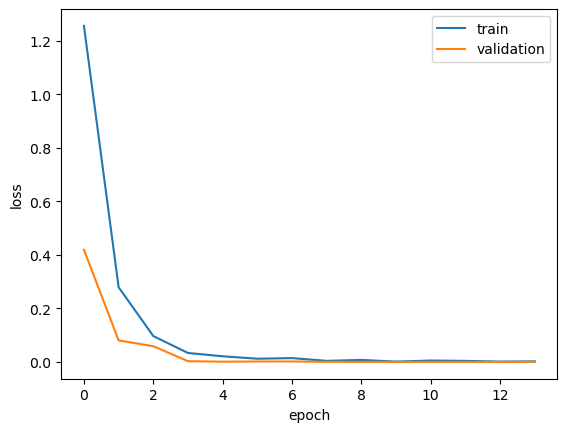

In [25]:
import matplotlib.pyplot as plt

# epoch vs. loss 그래프
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'validation'])
plt.show()

In [26]:
model.evaluate(val_scaled, val_target)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 6.8297e-05


[6.829697667853907e-05, 1.0]

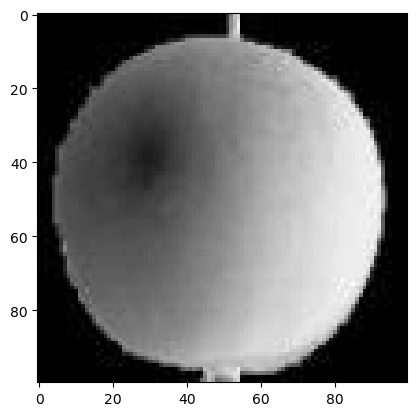

In [32]:
# 이미지 테스트
plt.imshow(
    (val_scaled[0] * 255).reshape(100, 100),
    cmap = 'gray'
)
plt.show()

In [37]:
pred = model.predict(
    val_scaled[:1]
)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


array([[9.9918264e-01, 8.0950226e-04, 7.8640151e-06]], dtype=float32)

In [38]:
label = ['apple', 'pine apple', 'bannana']

print(label[np.argmax(pred)])

apple


In [39]:
# test data 확인
model.evaluate(test_scaled, test_target)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 1.0652e-04


[0.00010652482160367072, 1.0]